In [2]:
from google.colab import files
Uploaded = files.upload()

Saving restaurant_dataset.csv to restaurant_dataset.csv


# Week 1 - EDA & Data Ingestion

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf

# Loading dataset

In [ ]:
df = pd.read_csv("restaurant_dataset.csv")
print(df)

          date  restaurant_id restaurant_type       menu_item_name meal_type  \
0     1/1/2024             11      Food Stall                Laksa     Lunch   
1     1/1/2024              7   Casual Dining  Spaghetti Carbonara    Dinner   
2     1/1/2024             23     Fine Dining         Beef Rendang    Dinner   
3     1/1/2024             22      Food Stall           Roti Canai    Dinner   
4     1/1/2024             32     Fine Dining  Spaghetti Carbonara     Lunch   
...        ...            ...             ...                  ...       ...   
9995  1/1/2025             45      Food Stall               Cendol    Dinner   
9996  1/1/2025             44      Food Stall            Teh Tarik     Lunch   
9997  1/1/2025             38     Fine Dining       Iced Lemon Tea    Dinner   
9998  1/1/2025              3            Cafe               Cendol     Lunch   
9999  1/1/2025             38     Fine Dining       Iced Lemon Tea    Dinner   

                                   key_

# EDA

In [7]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,weather_condition
0,1/1/2024,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,10.59,12.48,361,False,False,Sunny
1,1/1/2024,7,Casual Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,26.64,60.46,105,False,False,Sunny
2,1/1/2024,23,Fine Dining,Beef Rendang,Dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.0,49.42,80.15,36,False,False,Rainy
3,1/1/2024,22,Food Stall,Roti Canai,Dinner,"flour, ghee, egg, water, curry",0.8,2.04,2.48,503,False,False,Sunny
4,1/1/2024,32,Fine Dining,Spaghetti Carbonara,Lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,40.30,55.54,262,False,False,Rainy


In [8]:
print("\nSummary of dataset:")
df.info()

print("\nStatistics:")
df.describe()

print("\nShape:")
df.shape


Summary of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     10000 non-null  object 
 1   restaurant_id            10000 non-null  int64  
 2   restaurant_type          10000 non-null  object 
 3   menu_item_name           10000 non-null  object 
 4   meal_type                10000 non-null  object 
 5   key_ingredients_tags     10000 non-null  object 
 6   typical_ingredient_cost  10000 non-null  float64
 7   observed_market_price    10000 non-null  float64
 8   actual_selling_price     10000 non-null  float64
 9   quantity_sold            10000 non-null  int64  
 10  has_promotion            10000 non-null  bool   
 11  special_event            10000 non-null  bool   
 12  weather_condition        10000 non-null  object 
dtypes: bool(2), float64(3), int64(2), object(6)
memory usage

(10000, 13)

In [9]:
print("\nMissing values:")
df.isnull().sum()


Missing values:


,0
date,0
restaurant_id,0
restaurant_type,0
menu_item_name,0
meal_type,0
key_ingredients_tags,0
typical_ingredient_cost,0
observed_market_price,0
actual_selling_price,0
quantity_sold,0


# Date-Time conversion

In [10]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Remove rows with invalid dates
df = df.dropna(subset=["date"]).copy()

In [11]:
# Aggregate to daily sales
# Since this dataset has multiple rows per day, create a daily time series
daily_sales = (
    df.groupby("date", as_index=False)["quantity_sold"]
      .sum()
      .rename(columns={"quantity_sold": "daily_quantity_sold"})
)

# Sort by date
daily_sales = daily_sales.sort_values("date")

# Set datetime index
daily_sales = daily_sales.set_index("date")

print("\nDaily aggregated data:")
print(daily_sales.head())


Daily aggregated data:
            daily_quantity_sold
date                           
2024-01-01                 8479
2024-01-02                 7647
2024-01-03                 4172
2024-01-04                 7592
2024-01-05                 6712


In [12]:
# Make datetime index continuous

full_range = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D"
)

daily_sales = daily_sales.reindex(full_range)
daily_sales.index.name = "date"

print("\nMissing dates after reindexing:",
      daily_sales["daily_quantity_sold"].isna().sum())

# Fill missing dates
daily_sales["daily_quantity_sold"] = daily_sales["daily_quantity_sold"].fillna(0)

print("\nAfter filling missing dates:")
print(daily_sales.head())


Missing dates after reindexing: 0

After filling missing dates:
            daily_quantity_sold
date                           
2024-01-01                 8479
2024-01-02                 7647
2024-01-03                 4172
2024-01-04                 7592
2024-01-05                 6712


# Overall sales trend

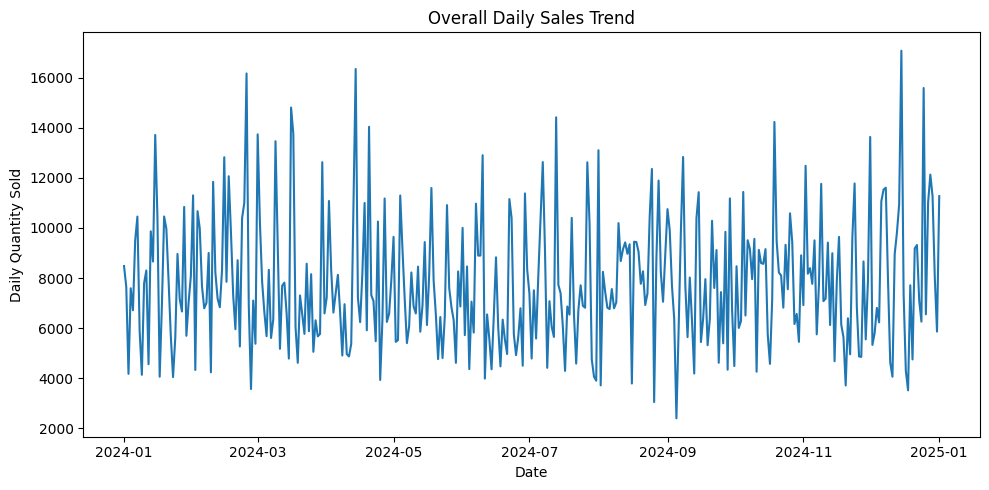

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(daily_sales.index, daily_sales["daily_quantity_sold"])
plt.title("Overall Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Daily Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1115/2774070122.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = daily_sales["daily_quantity_sold"].resample("M").sum()


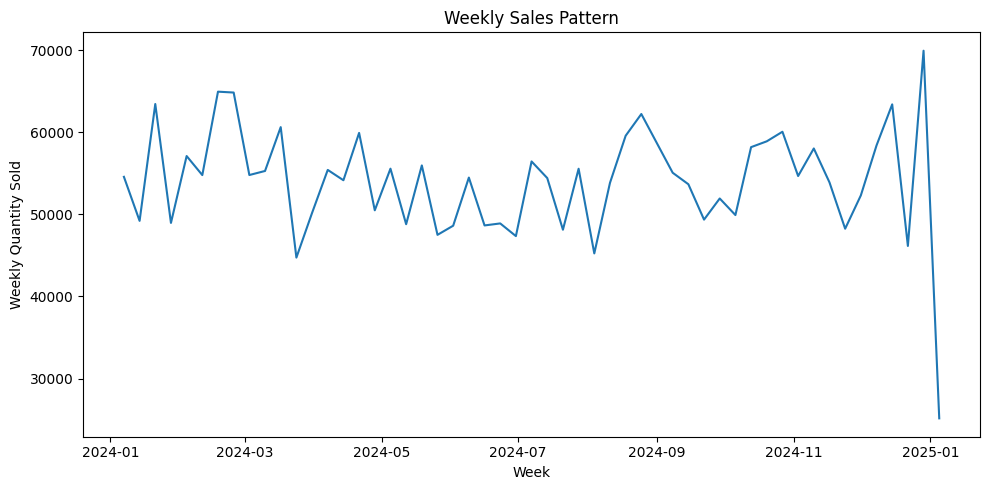

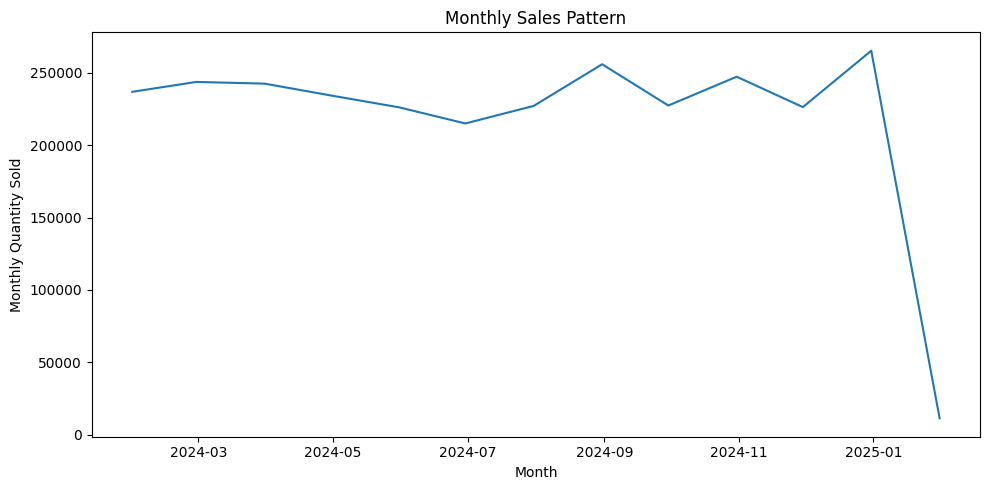

In [22]:
#  Weekly and monthly patterns

weekly_sales = daily_sales["daily_quantity_sold"].resample("W").sum()
monthly_sales = daily_sales["daily_quantity_sold"].resample("M").sum()

plt.figure(figsize=(10, 5))
plt.plot(weekly_sales.index, weekly_sales.values)
plt.title("Weekly Sales Pattern")
plt.xlabel("Week")
plt.ylabel("Weekly Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Monthly Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

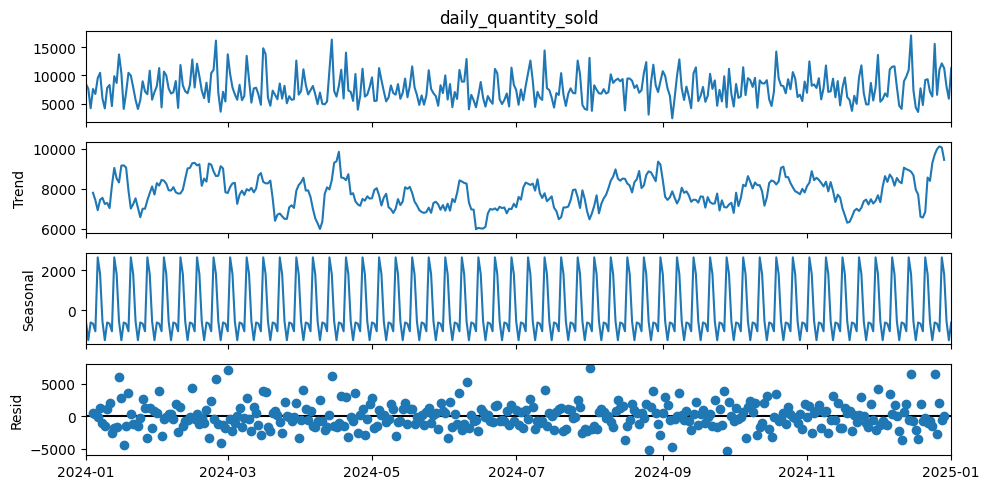

In [23]:
# Seasonal decomposition
# Weekly seasonality -> period=7 for daily data
decomposition = seasonal_decompose(
    daily_sales["daily_quantity_sold"],
    model="additive",
    period=7
)

fig = decomposition.plot()
fig.set_size_inches(10, 5)
plt.tight_layout()
plt.show()

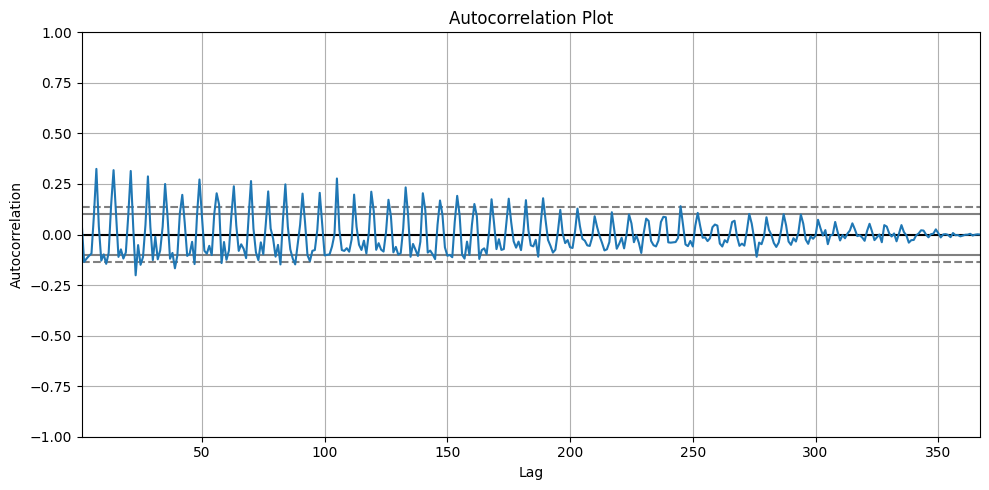

<Figure size 1000x500 with 0 Axes>

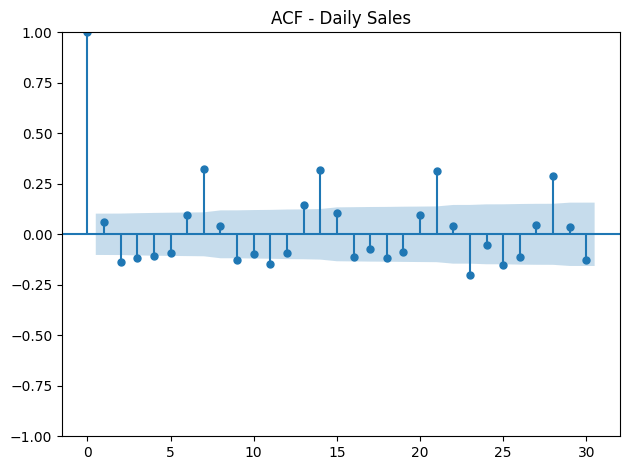

In [24]:
#  Autocorrelation analysis

plt.figure(figsize=(10, 5))
autocorrelation_plot(daily_sales["daily_quantity_sold"])
plt.title("Autocorrelation Plot")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plot_acf(daily_sales["daily_quantity_sold"], lags=30)
plt.title("ACF - Daily Sales")
plt.tight_layout()
plt.show()

# Week 2 – Feature Engineering & Data Preparation

This week we build the features the model will actually learn from:
1. **Rolling-window statistics** — capture recent trends
2. **Lag features** — give the model historical context
3. **Encoding categorical columns** — convert text labels to numbers
4. **Train / test split** — evaluate on unseen future data

## 1. Rolling-Window Statistics

Rolling statistics summarise the recent past over a sliding window.
They help the model understand **trends** and **local volatility** without hard-coding fixed look-back periods.

In [ ]:
# ── Rolling-window features ──────────────────────────────────────────────────
# Work on a fresh copy so the original daily_sales is untouched
features_df = daily_sales.copy()

# 7-day rolling mean & std  (captures weekly trend)
features_df["rolling_mean_7"]  = features_df["daily_quantity_sold"].rolling(window=7).mean()
features_df["rolling_std_7"]   = features_df["daily_quantity_sold"].rolling(window=7).std()

# 14-day rolling mean & std  (captures bi-weekly trend)
features_df["rolling_mean_14"] = features_df["daily_quantity_sold"].rolling(window=14).mean()
features_df["rolling_std_14"]  = features_df["daily_quantity_sold"].rolling(window=14).std()

# 30-day rolling mean  (captures monthly trend)
features_df["rolling_mean_30"] = features_df["daily_quantity_sold"].rolling(window=30).mean()

print("Rolling-window features added:")
print(features_df[["daily_quantity_sold",
                    "rolling_mean_7", "rolling_std_7",
                    "rolling_mean_14", "rolling_std_14",
                    "rolling_mean_30"]].head(35))


Rolling-window features added:
            daily_quantity_sold  rolling_mean_7  rolling_std_7  \
date                                                             
2024-01-01                 8479             NaN            NaN   
2024-01-02                 7647             NaN            NaN   
2024-01-03                 4172             NaN            NaN   
2024-01-04                 7592             NaN            NaN   
2024-01-05                 6712             NaN            NaN   
2024-01-06                 9503             NaN            NaN   
2024-01-07                10455     7794.285714    2033.996371   
2024-01-08                 5889     7424.285714    2122.334698   
2024-01-09                 4134     6922.428571    2450.822369   
2024-01-10                 7790     7439.285714    2135.299176   
2024-01-11                 8302     7540.714286    2160.476623   
2024-01-12                 4558     7233.000000    2434.233486   
2024-01-13                 9867     7285.0000

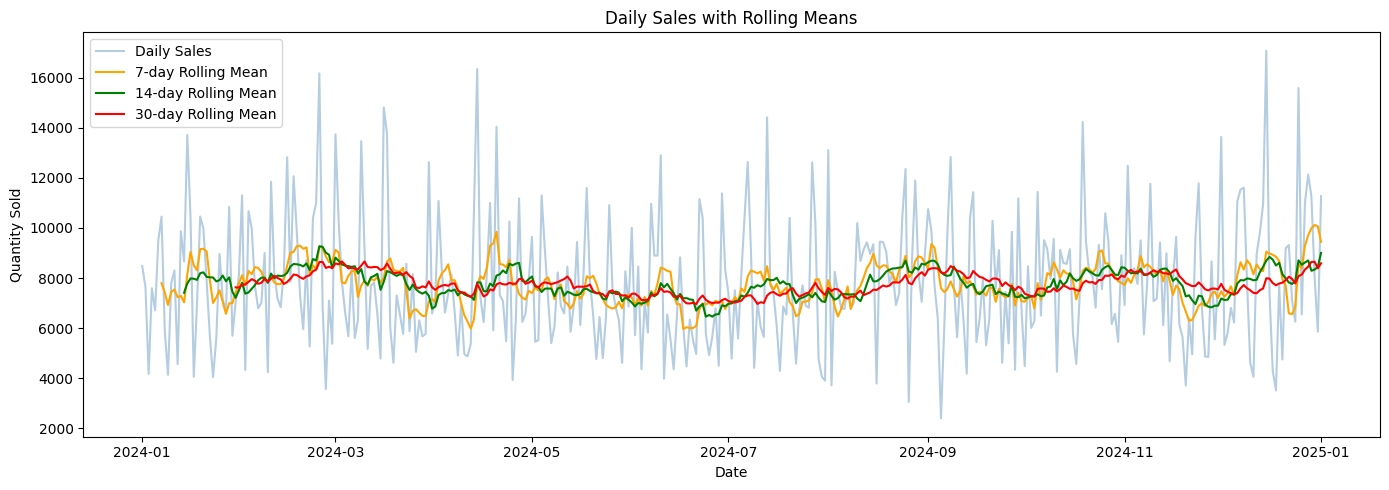

In [ ]:
# ── Visualise rolling means alongside raw sales ───────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(features_df.index, features_df["daily_quantity_sold"],
         alpha=0.4, label="Daily Sales", color="steelblue")
plt.plot(features_df.index, features_df["rolling_mean_7"],
         label="7-day Rolling Mean",  color="orange")
plt.plot(features_df.index, features_df["rolling_mean_14"],
         label="14-day Rolling Mean", color="green")
plt.plot(features_df.index, features_df["rolling_mean_30"],
         label="30-day Rolling Mean", color="red")
plt.title("Daily Sales with Rolling Means")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.tight_layout()
plt.show()


## 2. Lag Features

A **lag feature** is simply the value of a variable at a previous time step.
Lag-1 = yesterday's sales, Lag-7 = sales one week ago, etc.
They give the model explicit memory of the recent past.

In [ ]:
# ── Lag features ─────────────────────────────────────────────────────────────
features_df["lag_1"]  = features_df["daily_quantity_sold"].shift(1)   # yesterday
features_df["lag_7"]  = features_df["daily_quantity_sold"].shift(7)   # last week (same weekday)
features_df["lag_14"] = features_df["daily_quantity_sold"].shift(14)  # two weeks ago
features_df["lag_30"] = features_df["daily_quantity_sold"].shift(30)  # ~one month ago

print("Lag features added:")
print(features_df[["daily_quantity_sold",
                    "lag_1", "lag_7", "lag_14", "lag_30"]].head(35))


Lag features added:
            daily_quantity_sold    lag_1    lag_7   lag_14  lag_30
date                                                              
2024-01-01                 8479      NaN      NaN      NaN     NaN
2024-01-02                 7647   8479.0      NaN      NaN     NaN
2024-01-03                 4172   7647.0      NaN      NaN     NaN
2024-01-04                 7592   4172.0      NaN      NaN     NaN
2024-01-05                 6712   7592.0      NaN      NaN     NaN
2024-01-06                 9503   6712.0      NaN      NaN     NaN
2024-01-07                10455   9503.0      NaN      NaN     NaN
2024-01-08                 5889  10455.0   8479.0      NaN     NaN
2024-01-09                 4134   5889.0   7647.0      NaN     NaN
2024-01-10                 7790   4134.0   4172.0      NaN     NaN
2024-01-11                 8302   7790.0   7592.0      NaN     NaN
2024-01-12                 4558   8302.0   6712.0      NaN     NaN
2024-01-13                 9867   4558.0  

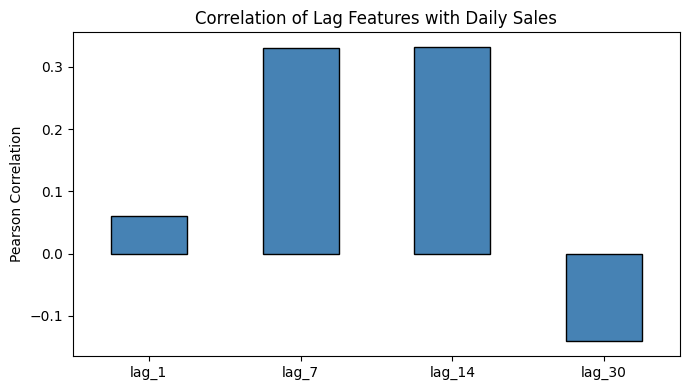


Correlation values:
lag_1     0.060912
lag_7     0.330379
lag_14    0.331921
lag_30   -0.140925
Name: daily_quantity_sold, dtype: float64


In [ ]:
# ── Correlation of lags with the target ──────────────────────────────────────
lag_cols = ["lag_1", "lag_7", "lag_14", "lag_30"]
correlations = features_df[["daily_quantity_sold"] + lag_cols].corr()["daily_quantity_sold"].drop("daily_quantity_sold")

plt.figure(figsize=(7, 4))
correlations.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Correlation of Lag Features with Daily Sales")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nCorrelation values:")
print(correlations)


## 3. Encoding Categorical Columns

Models need **numbers**, not strings. We first extract useful calendar features (day-of-week, month, etc.) and then encode any remaining categorical columns.

### 3a. Extract calendar features from the date index

In [ ]:
# ── Calendar features from the datetime index ────────────────────────────────
features_df["day_of_week"]  = features_df.index.dayofweek      # 0=Mon … 6=Sun
features_df["day_of_month"] = features_df.index.day
features_df["week_of_year"] = features_df.index.isocalendar().week.astype(int)
features_df["month"]        = features_df.index.month
features_df["quarter"]      = features_df.index.quarter
features_df["is_weekend"]   = (features_df["day_of_week"] >= 5).astype(int)

print("Calendar features:")
print(features_df[["day_of_week", "day_of_month",
                    "week_of_year", "month",
                    "quarter", "is_weekend"]].head(10))


Calendar features:
            day_of_week  day_of_month  week_of_year  month  quarter  \
date                                                                  
2024-01-01            0             1             1      1        1   
2024-01-02            1             2             1      1        1   
2024-01-03            2             3             1      1        1   
2024-01-04            3             4             1      1        1   
2024-01-05            4             5             1      1        1   
2024-01-06            5             6             1      1        1   
2024-01-07            6             7             1      1        1   
2024-01-08            0             8             2      1        1   
2024-01-09            1             9             2      1        1   
2024-01-10            2            10             2      1        1   

            is_weekend  
date                    
2024-01-01           0  
2024-01-02           0  
2024-01-03           0  
202

### 3b. Label Encoding

Use **Label Encoding** when a column has an **ordinal** (ordered) relationship — e.g., `low < medium < high`.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Example: create a synthetic 'season' column to demonstrate label encoding
season_map = {1: "Winter", 2: "Winter", 3: "Spring",
              4: "Spring",  5: "Spring", 6: "Summer",
              7: "Summer",  8: "Summer", 9: "Autumn",
              10: "Autumn", 11: "Autumn", 12: "Winter"}

features_df["season"] = features_df["month"].map(season_map)
print("Season column (before encoding):")
print(features_df["season"].value_counts())

le = LabelEncoder()
features_df["season_encoded"] = le.fit_transform(features_df["season"])

print("\nLabel encoding mapping:")
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {code}")

print("\nSample rows:")
print(features_df[["season", "season_encoded"]].head(10))


Season column (before encoding):
season
Winter    92
Spring    92
Summer    92
Autumn    91
Name: count, dtype: int64

Label encoding mapping:
  Autumn → 0
  Spring → 1
  Summer → 2
  Winter → 3

Sample rows:
            season  season_encoded
date                              
2024-01-01  Winter               3
2024-01-02  Winter               3
2024-01-03  Winter               3
2024-01-04  Winter               3
2024-01-05  Winter               3
2024-01-06  Winter               3
2024-01-07  Winter               3
2024-01-08  Winter               3
2024-01-09  Winter               3
2024-01-10  Winter               3


### 3c. One-Hot Encoding

Use **One-Hot Encoding** for **nominal** (unordered) categories — e.g., day-of-week names. Each category becomes its own binary column.

In [ ]:
# ── One-hot encode day_of_week ────────────────────────────────────────────────
day_names = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}
features_df["day_name"] = features_df["day_of_week"].map(day_names)

ohe_days = pd.get_dummies(features_df["day_name"], prefix="day", dtype=int)
features_df = pd.concat([features_df, ohe_days], axis=1)

print("One-hot encoded day columns:")
print(features_df[[c for c in features_df.columns if c.startswith("day_")]].head(10))


One-hot encoded day columns:
            day_of_week  day_of_month day_name  day_Fri  day_Mon  day_Sat  \
date                                                                        
2024-01-01            0             1      Mon        0        1        0   
2024-01-02            1             2      Tue        0        0        0   
2024-01-03            2             3      Wed        0        0        0   
2024-01-04            3             4      Thu        0        0        0   
2024-01-05            4             5      Fri        1        0        0   
2024-01-06            5             6      Sat        0        0        1   
2024-01-07            6             7      Sun        0        0        0   
2024-01-08            0             8      Mon        0        1        0   
2024-01-09            1             9      Tue        0        0        0   
2024-01-10            2            10      Wed        0        0        0   

            day_Sun  day_Thu  day_Tue  day_Wed

### 3d. Cyclic Encoding

Calendar values like **month (1–12)** or **day-of-week (0–6)** are *cyclic* — December is as close to January as February is.
Representing them with sine/cosine captures this circular structure.

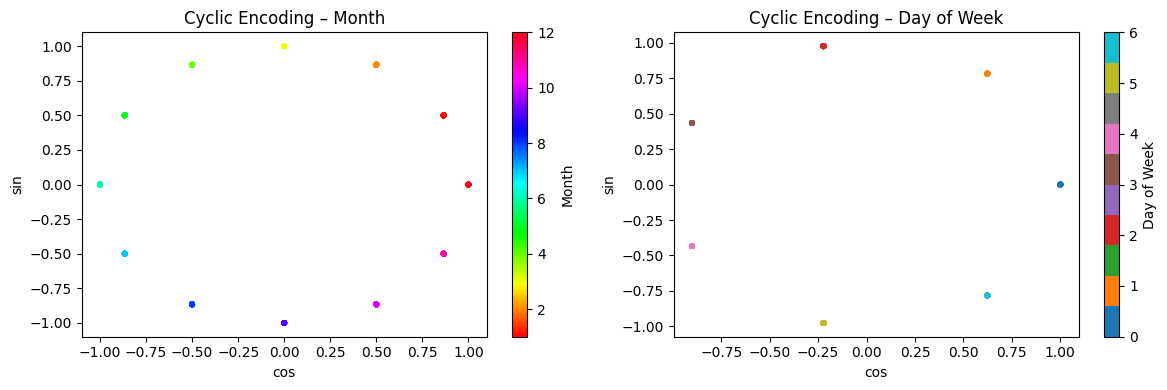

Cyclic feature sample:
            month  month_sin  month_cos  day_of_week   dow_sin   dow_cos
date                                                                    
2024-01-01      1        0.5   0.866025            0  0.000000  1.000000
2024-01-02      1        0.5   0.866025            1  0.781831  0.623490
2024-01-03      1        0.5   0.866025            2  0.974928 -0.222521
2024-01-04      1        0.5   0.866025            3  0.433884 -0.900969
2024-01-05      1        0.5   0.866025            4 -0.433884 -0.900969
2024-01-06      1        0.5   0.866025            5 -0.974928 -0.222521
2024-01-07      1        0.5   0.866025            6 -0.781831  0.623490
2024-01-08      1        0.5   0.866025            0  0.000000  1.000000


In [ ]:
# ── Cyclic encoding for month and day_of_week ─────────────────────────────────
features_df["month_sin"] = np.sin(2 * np.pi * features_df["month"] / 12)
features_df["month_cos"] = np.cos(2 * np.pi * features_df["month"] / 12)

features_df["dow_sin"]   = np.sin(2 * np.pi * features_df["day_of_week"] / 7)
features_df["dow_cos"]   = np.cos(2 * np.pi * features_df["day_of_week"] / 7)

# Visualise the cyclic encoding for month
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sc = axes[0].scatter(features_df["month_cos"], features_df["month_sin"],
                     c=features_df["month"], cmap="hsv", s=10)
plt.colorbar(sc, ax=axes[0], label="Month")
axes[0].set_title("Cyclic Encoding – Month")
axes[0].set_xlabel("cos"); axes[0].set_ylabel("sin")

sc2 = axes[1].scatter(features_df["dow_cos"], features_df["dow_sin"],
                      c=features_df["day_of_week"], cmap="tab10", s=10)
plt.colorbar(sc2, ax=axes[1], label="Day of Week")
axes[1].set_title("Cyclic Encoding – Day of Week")
axes[1].set_xlabel("cos"); axes[1].set_ylabel("sin")
plt.tight_layout()
plt.show()

print("Cyclic feature sample:")
print(features_df[["month", "month_sin", "month_cos",
                   "day_of_week", "dow_sin", "dow_cos"]].head(8))


## 4. Drop Rows with NaN (created by lags/rolling windows)

The first N rows will contain `NaN` values because there is no history to look back on. We drop them before splitting.

In [ ]:
print(f"Shape before dropping NaNs: {features_df.shape}")
print(f"Total NaN cells: {features_df.isna().sum().sum()}")

features_df.dropna(inplace=True)

print(f"Shape after  dropping NaNs: {features_df.shape}")
print(f"Total NaN cells after drop: {features_df.isna().sum().sum()}")


Shape before dropping NaNs: (367, 30)
Total NaN cells: 119
Shape after  dropping NaNs: (337, 30)
Total NaN cells after drop: 0


## 5. Train / Test Split

For time-series data we **never shuffle** — we split chronologically.
The model trains on the past and is evaluated on the future.

> Rule of thumb: **80 % train / 20 % test** (or use a fixed cut-off date).

In [ ]:
# ── Chronological 80/20 split ─────────────────────────────────────────────────
target_col  = "daily_quantity_sold"
feature_cols = [c for c in features_df.columns
                if c not in [target_col, "season", "day_name"]]   # drop raw categoricals

X = features_df[feature_cols]
y = features_df[target_col]

split_idx = int(len(features_df) * 0.80)
split_date = features_df.index[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Split date      : {split_date.date()}")
print(f"Training period : {X_train.index.min().date()}  →  {X_train.index.max().date()}  ({len(X_train)} days)")
print(f"Test period     : {X_test.index.min().date()}   →  {X_test.index.max().date()}   ({len(X_test)} days)")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")


Split date      : 2024-10-26
Training period : 2024-01-31  →  2024-10-25  (269 days)
Test period     : 2024-10-26   →  2025-01-01   (68 days)

X_train shape: (269, 27)
X_test  shape: (68, 27)


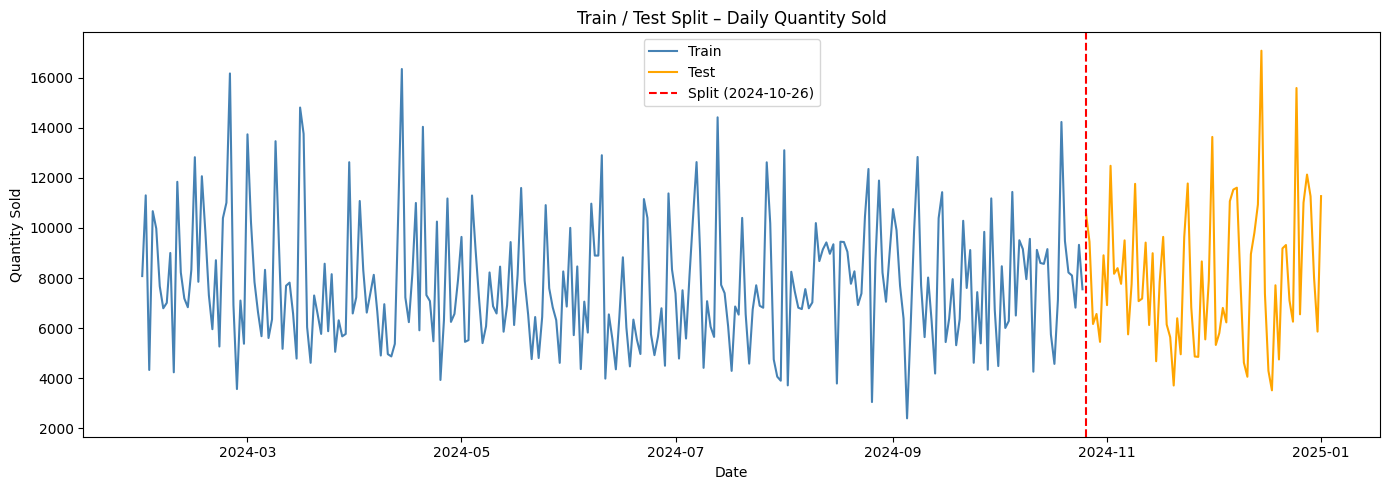

In [ ]:
# ── Visualise the train / test split ─────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train, label="Train", color="steelblue")
plt.plot(y_test.index,  y_test,  label="Test",  color="orange")
plt.axvline(split_date, color="red", linestyle="--", label=f"Split ({split_date.date()})")
plt.title("Train / Test Split – Daily Quantity Sold")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Final Feature Matrix Summary

In [ ]:
print("=== WEEK 2 FEATURE SUMMARY ===\n")
print(f"Total features  : {len(feature_cols)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples    : {len(X_test)}")
print("\nFeature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print("\nFirst 5 rows of final training feature matrix:")
print(X_train.head())


=== WEEK 2 FEATURE SUMMARY ===

Total features  : 27
Training samples: 269
Test samples    : 68

Feature columns:
   1. rolling_mean_7
   2. rolling_std_7
   3. rolling_mean_14
   4. rolling_std_14
   5. rolling_mean_30
   6. lag_1
   7. lag_7
   8. lag_14
   9. lag_30
  10. day_of_week
  11. day_of_month
  12. week_of_year
  13. month
  14. quarter
  15. is_weekend
  16. season_encoded
  17. day_Fri
  18. day_Mon
  19. day_Sat
  20. day_Sun
  21. day_Thu
  22. day_Tue
  23. day_Wed
  24. month_sin
  25. month_cos
  26. dow_sin
  27. dow_cos

First 5 rows of final training feature matrix:
            rolling_mean_7  rolling_std_7  rolling_mean_14  rolling_std_14  \
date                                                                         
2024-01-31     7776.571429    1702.513520      7500.000000     2002.857113   
2024-02-01     8111.000000    2146.270952      7813.000000     2234.427788   
2024-02-02     7706.571429    2578.718083      7375.071429     2276.360910   
2024-02-03    